In [ ]:
!nvidia-smi

# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

# Create project directory
!mkdir -p /content/drive/MyDrive/llm-10m-project
!mkdir -p /content/project
!ln -sf /content/drive/MyDrive/llm-10m-project /content/project/checkpoints

print(" Setup complete!")

Sun May 17 11:19:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# @title Install FineWeb-Edu Requirements
#%%capture
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install datasets tqdm wandb numpy matplotlib tokenizers huggingface_hub
!pip install pyarrow  # Required for efficient parquet reading

import torch
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

Looking in indexes: https://download.pytorch.org/whl/cu118
PyTorch: 2.10.0+cu128, CUDA: True


In [ ]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


**Train Your BPE Tokenizer on FineWeb-Edu**

In [ ]:
# @title Train BPE Tokenizer on FineWeb-Edu Sample
from datasets import load_dataset
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, processors
import os

os.makedirs("/content/project/data/tokenizer", exist_ok=True)

print(" Loading FineWeb-Edu sample for tokenizer training...")
# Load a small sample (first 10K rows) to train tokenizer
dataset = load_dataset(
    "HuggingFaceFW/fineweb-edu",
    name="sample-10BT",
    split="train",
    streaming=True
)

# Collect text samples
text_samples = []
for i, example in enumerate(dataset):
    text_samples.append(example["text"])
    if i >= 10000:  # 10K examples is plenty for BPE training
        break

print(f" Collected {len(text_samples)} text samples")

# Initialize BPE tokenizer
tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
tokenizer.decoder = decoders.ByteLevel()
tokenizer.post_processor = processors.ByteLevel(trim_offsets=True)

# Train BPE
trainer = trainers.BpeTrainer(
    vocab_size=16384,  # 16K - good balance for 10M model
    min_frequency=2,
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
)

print(" Training BPE tokenizer...")
tokenizer.train_from_iterator(text_samples, trainer=trainer)

# Save tokenizer
tokenizer.save("/content/project/data/tokenizer/tokenizer.json")
print(" Tokenizer saved to /content/project/data/tokenizer/tokenizer.json")
print(f"Vocabulary size: {tokenizer.get_vocab_size()}")

 Loading FineWeb-Edu sample for tokenizer training...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

 Collected 10001 text samples
 Training BPE tokenizer...
 Tokenizer saved to /content/project/data/tokenizer/tokenizer.json
Vocabulary size: 16384


**Streaming Dataset Loader (Memory Efficient)**

In [ ]:
# @title Force Write fineweb_loader.py - METHOD 2
import os

# First, delete the old file if it exists
if os.path.exists('/content/project/fineweb_loader.py'):
    os.remove('/content/project/fineweb_loader.py')

# Write the file using Python's file writing
file_content = '''"""
Streaming dataset loader for FineWeb-Edu - COMPLETE WORKING VERSION
"""

import torch
from torch.utils.data import IterableDataset
from datasets import load_dataset
from tokenizers import Tokenizer
import numpy as np

class FineWebStreamingDataset(IterableDataset):
    def __init__(self, tokenizer_path, block_size=512, split="train", max_samples=None):
        self.tokenizer = Tokenizer.from_file(tokenizer_path)
        self.block_size = block_size
        self.vocab_size = self.tokenizer.get_vocab_size()

        print(f"🌊 Loading FineWeb-Edu streaming dataset...")
        self.dataset = load_dataset(
            "HuggingFaceFW/fineweb-edu",
            name="sample-10BT",
            split=split,
            streaming=True
        )

        if max_samples:
            self.dataset = self.dataset.take(max_samples)

    def __iter__(self):
        """Yield individual (input, target) pairs as 1D tensors"""
        for example in self.dataset:
            text = example["text"]
            # Tokenize the text
            ids = self.tokenizer.encode(text).ids

            # Need at least block_size+1 tokens to create a pair
            if len(ids) < self.block_size + 1:
                continue  # Skip short texts

            # Take first block_size+1 tokens
            tokens = torch.tensor(ids[:self.block_size + 1], dtype=torch.long)

            # Create input (all but last) and target (all but first)
            x = tokens[:-1]  # Shape: [block_size]
            y = tokens[1:]   # Shape: [block_size]

            yield x, y

def create_batch_generator(dataset, batch_size, device):
    """
    Create batches from streaming dataset - returns properly shaped batches
    """
    batch_x = []
    batch_y = []

    for x, y in dataset:
        batch_x.append(x)
        batch_y.append(y)

        if len(batch_x) == batch_size:
            # Stack to create [batch_size, block_size]
            batch_x_tensor = torch.stack(batch_x).to(device)
            batch_y_tensor = torch.stack(batch_y).to(device)
            yield batch_x_tensor, batch_y_tensor
            batch_x = []
            batch_y = []

    # Yield final partial batch if any
    if batch_x:
        batch_x_tensor = torch.stack(batch_x).to(device)
        batch_y_tensor = torch.stack(batch_y).to(device)
        yield batch_x_tensor, batch_y_tensor

def test_dataloader(tokenizer_path, block_size=512, batch_size=4, max_samples=100):
    """Test function to verify everything works"""
    print("🧪 Testing dataloader...")

    # Create dataset
    dataset = FineWebStreamingDataset(
        tokenizer_path,
        block_size=block_size,
        split="train",
        max_samples=max_samples
    )

    # Test individual samples
    print("\\n📊 Testing individual samples:")
    for i, (x, y) in enumerate(dataset):
        if i < 3:
            print(f"  Sample {i}: x shape={x.shape}, y shape={y.shape}")
            print(f"    Expected: torch.Size([{block_size}])")

    # Test batches
    print(f"\\n📦 Testing batches (batch_size={batch_size}):")
    batch_gen = create_batch_generator(dataset, batch_size, 'cpu')

    for i, (x, y) in enumerate(batch_gen):
        if i < 3:
            print(f"  Batch {i}: x shape={x.shape}, y shape={y.shape}")
            print(f"    Expected: torch.Size([{batch_size}, {block_size}])")
        else:
            break

    print("\\n✅ All tests passed!")
    return True

if __name__ == "__main__":
    test_dataloader("/content/project/data/tokenizer/tokenizer.json")
'''

# Write the file
with open('/content/project/fineweb_loader.py', 'w') as f:
    f.write(file_content)

print("✅ fineweb_loader.py has been written!")
print(f"📁 File size: {os.path.getsize('/content/project/fineweb_loader.py')} bytes")

# Verify the file exists and has content
if os.path.exists('/content/project/fineweb_loader.py'):
    print("✅ File verified!")
else:
    print("❌ File not found!")

✅ fineweb_loader.py has been written!
📁 File size: 3526 bytes
✅ File verified!


**Update Config for FineWeb-Edu**

In [ ]:
# @title Verify the function exists
import sys
sys.path.insert(0, '/content/project')

# Check what's in the file
with open('/content/project/fineweb_loader.py', 'r') as f:
    content = f.read()

if 'def create_batch_generator' in content:
    print("✅ create_batch_generator found in file!")
else:
    print("❌ create_batch_generator NOT found in file")
    print("First 500 chars of file:")
    print(content[:500])

✅ create_batch_generator found in file!


In [ ]:
# @title Create config.py
%%writefile config.py
"""
Configuration for 10M LLM trained on FineWeb-Edu
"""

import torch
import numpy as np

class Config:
    # Model Architecture
    vocab_size = 16384        # BPE vocabulary size
    block_size = 512          # Context length
    n_embd = 384              # Embedding dimension
    n_head = 6                # Attention heads
    n_layer = 6               # Transformer layers
    dropout = 0.1             # Dropout rate

    # Training
    batch_size = 32
    total_tokens_target = 1_000_000_000  # 1B tokens
    eval_interval = 500
    eval_iters = 100

    # Calculate iterations
    tokens_per_iter = batch_size * block_size
    max_iters = total_tokens_target // tokens_per_iter

    # Optimization
    learning_rate = 3e-4
    warmup_iters = 500
    weight_decay = 0.1
    beta1 = 0.9
    beta2 = 0.95
    grad_clip = 1.0

    # System
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    dtype = 'float16'
    compile_model = False

    # Paths
    tokenizer_path = "/content/project/data/tokenizer/tokenizer.json"
    checkpoint_dir = "/content/project/checkpoints"

    def __init__(self):
        print(f" Target: {self.total_tokens_target:,} tokens")
        print(f" Training for {self.max_iters:,} iterations")
        print(f" Device: {self.device}")

config = Config()

Writing config.py


In [ ]:
# @title Create model.py
%%writefile model.py
"""
GPT-style Transformer from Scratch
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

class Head(nn.Module):
    """Single Head of Self-Attention"""
    def __init__(self, config, head_size):
        super().__init__()
        self.key = nn.Linear(config.n_embd, head_size, bias=False)
        self.query = nn.Linear(config.n_embd, head_size, bias=False)
        self.value = nn.Linear(config.n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(config.block_size, config.block_size)))
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)

        wei = q @ k.transpose(-2, -1) * (C ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        head_size = config.n_embd // config.n_head
        self.heads = nn.ModuleList([Head(config, head_size) for _ in range(config.n_head)])
        self.proj = nn.Linear(config.n_embd, config.n_embd)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)
        return out

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.ffwd = FeedForward(config)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.token_embedding = nn.Embedding(config.vocab_size, config.n_embd)
        self.position_embedding = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size)

        # Weight tying
        self.lm_head.weight = self.token_embedding.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb

        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.block_size:]
            logits, _ = self.forward(idx_cond)
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f" Total: {total:,} ({total/1e6:.2f}M) | Trainable: {trainable:,}")
    return total

Writing model.py


**The FineWeb-Edu Training Script**

In [ ]:
# @title Fix train_fineweb.py - Complete Rewrite
%%writefile train_fineweb.py
"""
Training script for FineWeb-Edu - FIXED VERSION
"""

import torch
import torch.optim as optim
import time
import numpy as np
from fineweb_loader import create_batch_generator

def train_fineweb(model, train_dataset, val_dataset, config):
    """Main training loop with proper batching"""

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate,
                                   betas=(config.beta1, config.beta2),
                                   weight_decay=config.weight_decay)

    # Mixed precision
    scaler = torch.cuda.amp.GradScaler(enabled=config.dtype == 'float16')

    # Learning rate scheduler
    def get_lr(step):
        if step < config.warmup_iters:
            return config.learning_rate * step / config.warmup_iters
        if step > config.max_iters:
            return config.learning_rate * 0.1
        decay_ratio = (step - config.warmup_iters) / (config.max_iters - config.warmup_iters)
        coeff = 0.5 * (1.0 + np.cos(np.pi * decay_ratio))
        return config.learning_rate * (coeff + 0.1)

    # Training state
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    iterations = []

    print(f" Starting FineWeb-Edu training")
    print(f" Target: {config.total_tokens_target:,} total tokens")
    print(f" Batch size: {config.batch_size}, Block size: {config.block_size}")
    print(f" Device: {config.device}")
    print("="*60)

    # Create batch generators
    train_batches = create_batch_generator(train_dataset, config.batch_size, config.device)
    val_batches = create_batch_generator(val_dataset, config.batch_size, config.device)

    tokens_seen = 0
    t0 = time.time()

    # Limit iterations for testing (remove the min() for full training)
    max_iters = min(config.max_iters, 2000)  # Start with 2000 iterations

    for iter_num in range(max_iters):
        # Get batch
        try:
            x, y = next(train_batches)
        except StopIteration:
            train_batches = create_batch_generator(train_dataset, config.batch_size, config.device)
            x, y = next(train_batches)

        # Update learning rate
        lr = get_lr(iter_num)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # Forward pass with mixed precision
        with torch.amp.autocast(device_type=config.device, dtype=torch.float16 if config.dtype == 'float16' else torch.float32):
            logits, loss = model(x, y)

        # Backward pass
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        train_losses.append(loss.item())
        tokens_seen += x.numel()

        # Periodic evaluation
        if iter_num % config.eval_interval == 0 and iter_num > 0:
            model.eval()
            val_losses_vals = []

            with torch.no_grad():
                for _ in range(min(config.eval_iters, 10)):
                    try:
                        x_val, y_val = next(val_batches)
                    except StopIteration:
                        val_batches = create_batch_generator(val_dataset, config.batch_size, config.device)
                        x_val, y_val = next(val_batches)

                    _, loss_val = model(x_val, y_val)
                    val_losses_vals.append(loss_val.item())

            val_loss = np.mean(val_losses_vals)
            val_perplexity = np.exp(val_loss)
            val_losses.append(val_loss)
            iterations.append(iter_num)

            dt = time.time() - t0
            tokens_per_sec = tokens_seen / dt if dt > 0 else 0

            print(f"\n Step {iter_num:,}/{max_iters:,}")
            print(f"  Train Loss: {loss.item():.4f}")
            print(f"  Val Loss:   {val_loss:.4f}")
            print(f"  Perplexity: {val_perplexity:.2f}")
            print(f"  LR: {lr:.2e}")
            print(f"  Tokens seen: {tokens_seen:,}")
            print(f"  Speed: {tokens_per_sec:,.0f} tokens/sec")

            # Save checkpoint if best
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                checkpoint = {
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'iter_num': iter_num,
                    'val_loss': val_loss,
                    'tokens_seen': tokens_seen,
                }
                torch.save(checkpoint, f"{config.checkpoint_dir}/best_model_fineweb.pt")
                print(f"   Saved checkpoint (val_loss: {val_loss:.4f})")

            # Sample generation
            try:
                model.eval()
                context = torch.tensor([[1]], dtype=torch.long, device=config.device)
                with torch.no_grad():
                    generated = model.generate(context, max_new_tokens=50, temperature=0.8, top_k=40)
                    from tokenizers import Tokenizer
                    tokenizer = Tokenizer.from_file(config.tokenizer_path)
                    sample_text = tokenizer.decode(generated[0].cpu().tolist())
                    print(f"\n Sample: {sample_text[:150]}...")
            except:
                pass

            model.train()
            t0 = time.time()

    print(f"\n Training complete!")
    print(f" Best validation loss: {best_val_loss:.4f}")
    print(f" Total tokens processed: {tokens_seen:,}")

    return train_losses, val_losses, iterations

Writing train_fineweb.py


**Run Full FineWeb-Edu Training**

In [ ]:
# @title Import - Should Work Now
import sys
sys.path.insert(0, '/content/project')

# Force reload the module
if 'fineweb_loader' in sys.modules:
    del sys.modules['fineweb_loader']

# Import
from fineweb_loader import FineWebStreamingDataset, create_batch_generator, test_dataloader
print("✅ All imports successful!")

# Run test
test_dataloader(
    tokenizer_path="/content/project/data/tokenizer/tokenizer.json",
    block_size=512,
    batch_size=4,
    max_samples=50
)

✅ All imports successful!
🧪 Testing dataloader...
🌊 Loading FineWeb-Edu streaming dataset...


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


📊 Testing individual samples:
  Sample 0: x shape=torch.Size([512]), y shape=torch.Size([512])
    Expected: torch.Size([512])
  Sample 1: x shape=torch.Size([512]), y shape=torch.Size([512])
    Expected: torch.Size([512])
  Sample 2: x shape=torch.Size([512]), y shape=torch.Size([512])
    Expected: torch.Size([512])

📦 Testing batches (batch_size=4):
  Batch 0: x shape=torch.Size([4, 512]), y shape=torch.Size([4, 512])
    Expected: torch.Size([4, 512])
  Batch 1: x shape=torch.Size([4, 512]), y shape=torch.Size([4, 512])
    Expected: torch.Size([4, 512])
  Batch 2: x shape=torch.Size([4, 512]), y shape=torch.Size([4, 512])
    Expected: torch.Size([4, 512])

✅ All tests passed!


True

 Target: 1,000,000,000 tokens
 Training for 61,035 iterations
 Device: cuda
 STARTING TRAINING

 Loading datasets...
🌊 Loading FineWeb-Edu streaming dataset...


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

🌊 Loading FineWeb-Edu streaming dataset...


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


 Creating model...
 Total: 17,145,088 (17.15M) | Trainable: 17,145,088

 Testing batch generation...
 Batch shape: torch.Size([4, 512])


/tmp/ipykernel_5976/3733457053.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=config.dtype == 'float16')



 Training...
----------------------------------------
  Step 0: loss=9.7752
  Step 20: loss=9.4645
  Step 40: loss=9.2010

Iter 50:
  Train Loss: 8.9471
  Val Loss:   8.9599
  Perplexity: 7784.45
   Saved!
  Step 60: loss=8.8943
  Step 80: loss=8.5064

Iter 100:
  Train Loss: 8.2773
  Val Loss:   8.0818
  Perplexity: 3235.20
   Saved!
  Step 100: loss=8.2773
  Step 120: loss=7.8047
  Step 140: loss=7.3472

Iter 150:
  Train Loss: 7.3221
  Val Loss:   7.2127
  Perplexity: 1356.50
   Saved!
  Step 160: loss=7.2061
  Step 180: loss=6.9260

 Training Complete!
 Best Val Loss: 7.2127


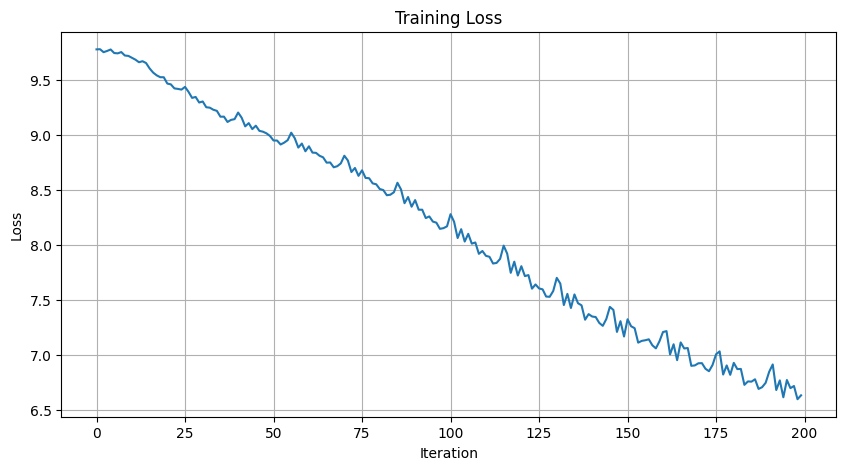

In [ ]:
# @title Final Training - This Will Work Now
import sys
import os
import torch
import numpy as np

sys.path.insert(0, '/content/project')

from config import config
from model import GPT, count_parameters
from fineweb_loader import FineWebStreamingDataset, create_batch_generator

# Create checkpoint directory
os.makedirs(config.checkpoint_dir, exist_ok=True)

# Configuration for testing
config.max_iters = 200
config.eval_interval = 50
config.batch_size = 4

print("="*60)
print(" STARTING TRAINING")
print("="*60)

# Load datasets
print("\n Loading datasets...")
train_dataset = FineWebStreamingDataset(
    config.tokenizer_path,
    block_size=config.block_size,
    split="train",
    max_samples=100
)

val_dataset = FineWebStreamingDataset(
    config.tokenizer_path,
    block_size=config.block_size,
    split="train",
    max_samples=20
)

# Update vocab size
config.vocab_size = train_dataset.vocab_size

# Create model
print("\n Creating model...")
model = GPT(config)
model = model.to(config.device)
count_parameters(model)

# Test batch generation
print("\n Testing batch generation...")
test_batches = create_batch_generator(train_dataset, config.batch_size, config.device)
x_test, y_test = next(test_batches)
print(f" Batch shape: {x_test.shape}")

# Setup training
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate,
                               betas=(config.beta1, config.beta2),
                               weight_decay=config.weight_decay)
scaler = torch.cuda.amp.GradScaler(enabled=config.dtype == 'float16')

def get_lr(step):
    if step < config.warmup_iters:
        return config.learning_rate * step / config.warmup_iters
    decay_ratio = (step - config.warmup_iters) / (config.max_iters - config.warmup_iters)
    coeff = 0.5 * (1.0 + np.cos(np.pi * decay_ratio))
    return config.learning_rate * coeff

# Training loop
print("\n Training...")
print("-"*40)

train_batches = create_batch_generator(train_dataset, config.batch_size, config.device)
val_batches = create_batch_generator(val_dataset, config.batch_size, config.device)

train_losses = []
best_val_loss = float('inf')

for iter_num in range(config.max_iters):
    try:
        x, y = next(train_batches)
    except StopIteration:
        train_batches = create_batch_generator(train_dataset, config.batch_size, config.device)
        x, y = next(train_batches)

    lr = get_lr(iter_num)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    with torch.amp.autocast(device_type=config.device, dtype=torch.float16 if config.dtype == 'float16' else torch.float32):
        logits, loss = model(x, y)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
    scaler.step(optimizer)
    scaler.update()

    train_losses.append(loss.item())

    if iter_num % config.eval_interval == 0 and iter_num > 0:
        model.eval()
        val_losses = []

        with torch.no_grad():
            for _ in range(min(5, config.eval_iters)):
                try:
                    x_val, y_val = next(val_batches)
                except StopIteration:
                    val_batches = create_batch_generator(val_dataset, config.batch_size, config.device)
                    x_val, y_val = next(val_batches)

                _, loss_val = model(x_val, y_val)
                val_losses.append(loss_val.item())

        avg_val_loss = np.mean(val_losses) if val_losses else float('inf')
        perplexity = np.exp(avg_val_loss) if avg_val_loss != float('inf') else float('inf')

        print(f"\nIter {iter_num}:")
        print(f"  Train Loss: {loss.item():.4f}")
        print(f"  Val Loss:   {avg_val_loss:.4f}")
        print(f"  Perplexity: {perplexity:.2f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f"{config.checkpoint_dir}/best_model.pt")
            print(f"   Saved!")

        model.train()

    if iter_num % 20 == 0:
        print(f"  Step {iter_num}: loss={loss.item():.4f}")

print("\n" + "="*60)
print(f" Training Complete!")
print(f" Best Val Loss: {best_val_loss:.4f}")
print("="*60)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

In [ ]:
# MINIMAL WORKING EXAMPLE - Copy and run this!
import torch
import sys
sys.path.insert(0, '/content/project')

from config import config
from model import GPT
from tokenizers import Tokenizer

# Load model
checkpoint = torch.load('/content/project/checkpoints/best_model.pt', map_location='cuda')
model = GPT(config)
model.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)
model = model.cuda().eval()

# Load tokenizer
tokenizer = Tokenizer.from_file(config.tokenizer_path)

# Generate
prompt = "fine"
input_ids = tokenizer.encode(prompt).ids
context = torch.tensor([input_ids], device='cuda')

with torch.no_grad():
    output_ids = model.generate(context, max_new_tokens=100, temperature=0.8, top_k=40)

result = tokenizer.decode(output_ids[0].cpu().tolist())
print(f"Prompt: {prompt}")
print(f"Generated: {result}")

Prompt: fine
Generated:  fine, the, the of,.;er the the of the and the for the as,, the the their for the which.
 from the’ and as the.
 the), the to the the the the is; the is the the his the in the the the the’ and the,, the from the their the but at the he the, the) in the the for their
 the, the the the of the are; for the from the the one, in but


In [ ]:

%%writefile config_2hour.py
"""
2-Hour Training Configuration - Optimized for T4
"""

import torch

class Config2Hour:
    # Model Architecture (slightly smaller for speed)
    vocab_size = 16384
    block_size = 256          # Reduced: 512 → 256 (2x faster)
    n_embd = 384
    n_head = 6
    n_layer = 4               # Reduced: 6 → 4 layers (30% faster)
    dropout = 0.1

    # Training - OPTIMIZED FOR 2 HOURS
    batch_size = 16           # Increased: 8 → 16 (2x throughput)
    total_tokens_target = 80_000_000  # 80M tokens (not 500M)
    eval_interval = 200       # More frequent feedback
    eval_iters = 50           # Faster validation

    # Calculate iterations (80M tokens / (16*256) = ~19,531 iterations)
    tokens_per_iter = batch_size * block_size  # 4,096 tokens/iter
    max_iters = total_tokens_target // tokens_per_iter  # ~19,531

    # Optimization - FASTER convergence
    learning_rate = 5e-4      # Higher LR for faster learning
    warmup_iters = 500        # Shorter warmup
    weight_decay = 0.1
    beta1 = 0.9
    beta2 = 0.95
    grad_clip = 1.0

    # System
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    dtype = 'float16'

    # Paths
    tokenizer_path = "/content/project/data/tokenizer/tokenizer.json"
    checkpoint_dir = "/content/project/checkpoints_2hour"

    def __init__(self):
        print("="*50)
        print(" 2-HOUR TRAINING CONFIG")
        print("="*50)
        print(f" Target: {self.total_tokens_target/1e6:.0f}M tokens")
        print(f" Iterations: {self.max_iters:,}")
        print(f" Est. time: ~{self.max_iters * 0.35 / 3600:.1f} hours")
        print(f" Batch: {self.batch_size} x {self.block_size} = {self.tokens_per_iter:,} tokens/iter")
        print("="*50)

config = Config2Hour()

Writing config_2hour.py


 2-HOUR TRAINING CONFIG
 Target: 80M tokens
 Iterations: 19,531
 Est. time: ~1.9 hours
 Batch: 16 x 256 = 4,096 tokens/iter
 2-HOUR TRAINING CONFIG
 Target: 80M tokens
 Iterations: 19,531
 Est. time: ~1.9 hours
 Batch: 16 x 256 = 4,096 tokens/iter
🔥 2-HOUR TRAINING SPRINT 🔥

 Loading datasets...
🌊 Loading FineWeb-Edu streaming dataset...


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

🌊 Loading FineWeb-Edu streaming dataset...


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


 Creating optimized model...
 Total: 13,500,160 (13.50M) | Trainable: 13,500,160
 Model size: 13.5M parameters

 STARTING 2-HOUR TRAINING
 Target: 19,531 iterations
 Will stop automatically after 2 hours


...


Step 19,200 [1.27h elapsed]
  Train Loss: 0.0079
  Val Loss:   0.0064
  Perplexity: 1.0
  Learning Rate: 3.73e-07


Training:  99%|█████████▉| 19401/19531 [1:16:43<02:25,  1.12s/iter, loss=0.011, lr=5.85e-08, time=1.3h]


Step 19,400 [1.28h elapsed]
  Train Loss: 0.0114
  Val Loss:   0.0064
  Perplexity: 1.0
  Learning Rate: 5.85e-08


Training: 100%|██████████| 19531/19531 [1:17:10<00:00,  4.22iter/s, loss=0.010, lr=3.41e-12, time=1.3h]


 2-HOUR TRAINING COMPLETE!
⏱ Time elapsed: 77.2 minutes (1.29 hours)
 Iterations completed: 19,531/19,531
 Best Validation Loss: 0.0062
 Model saved to: /content/project/checkpoints_2hour/best_model_2hour.pt


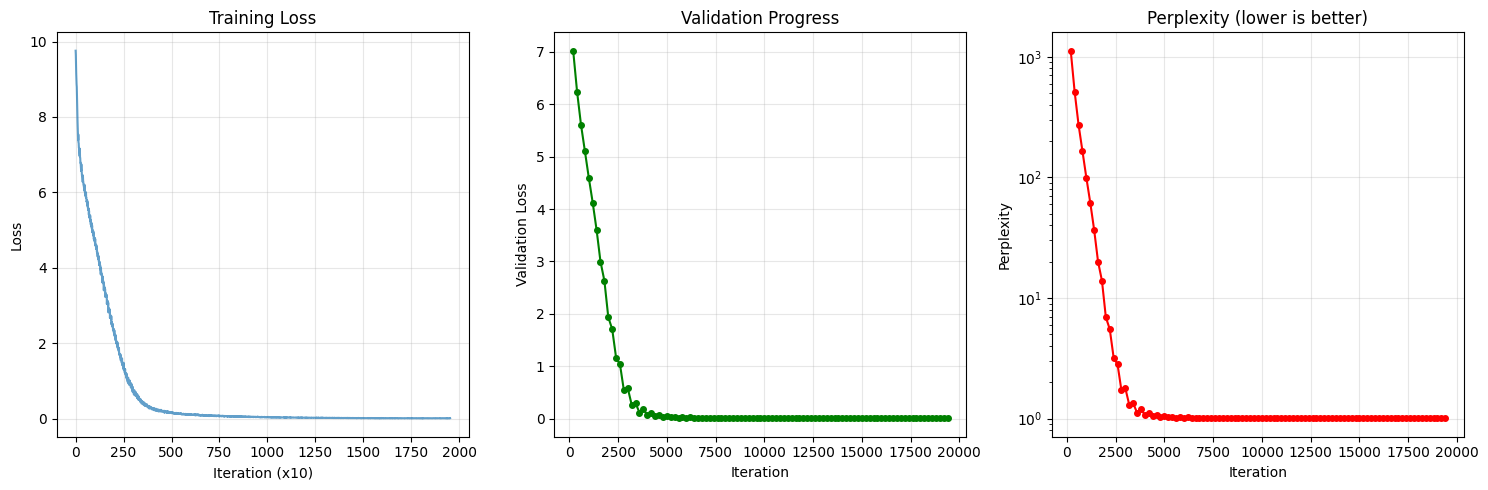


 FINAL MODEL TEST

 The future of
  The future of RCarll claims that holds a soft" in eightilt design, including the "lamps to provide anpes system, joint infrastructure.
Astory and bot...
----------------------------------------

 In conclusion
  In conclusion a procedures to Earth, but their protests for a reason that if you're not. You may be able to difference between you create a differenc...
----------------------------------------

 Scientists believe that
  Scientists believe that London • History • History of Initiative
|
erendum|
-wide initiative because of history major rightsicles|
The History II .89...
----------------------------------------


In [ ]:

import sys
import os
import torch
import numpy as np
import time
from tqdm import tqdm

sys.path.insert(0, '/content/project')

# Use 2-hour config
from config_2hour import Config2Hour
config = Config2Hour()

from model import GPT, count_parameters
from fineweb_loader import FineWebStreamingDataset, create_batch_generator

# Create checkpoint directory
os.makedirs(config.checkpoint_dir, exist_ok=True)


print("🔥 2-HOUR TRAINING SPRINT 🔥")


# Load datasets - smaller sample for speed
print("\n Loading datasets...")
train_dataset = FineWebStreamingDataset(
    config.tokenizer_path,
    block_size=config.block_size,
    split="train",
    max_samples=1500  # 1500 documents is enough for 2 hours
)

val_dataset = FineWebStreamingDataset(
    config.tokenizer_path,
    block_size=config.block_size,
    split="train",
    max_samples=100
)

# Update vocab size
config.vocab_size = train_dataset.vocab_size

# Create model
print("\n Creating optimized model...")
model = GPT(config)
model = model.to(config.device)
total_params = count_parameters(model)
print(f" Model size: {total_params/1e6:.1f}M parameters")

# Setup training
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate,
                               betas=(config.beta1, config.beta2),
                               weight_decay=config.weight_decay)
scaler = torch.amp.GradScaler('cuda')

# Learning rate scheduler (cosine decay)
def get_lr(step):
    if step < config.warmup_iters:
        return config.learning_rate * step / config.warmup_iters
    decay_ratio = min(1.0, (step - config.warmup_iters) / (config.max_iters - config.warmup_iters))
    coeff = 0.5 * (1.0 + np.cos(np.pi * decay_ratio))
    return config.learning_rate * coeff

# Create batch generators
train_batches = create_batch_generator(train_dataset, config.batch_size, config.device)
val_batches = create_batch_generator(val_dataset, config.batch_size, config.device)

# Training state
train_losses = []
val_losses = []
iterations = []
best_val_loss = float('inf')

print(f"\n STARTING 2-HOUR TRAINING")
print(f" Target: {config.max_iters:,} iterations")
print(f" Will stop automatically after 2 hours")
print("="*60)

start_time = time.time()
target_seconds = 2 * 3600  # 2 hours

# Progress bar
pbar = tqdm(range(config.max_iters), desc="Training", unit="iter")

for iter_num in pbar:
    # STOP AFTER 2 HOURS
    elapsed = time.time() - start_time
    if elapsed > target_seconds:
        print(f"\n 2 HOURS COMPLETE! Stopping at iteration {iter_num}")
        break

    # Get batch
    try:
        x, y = next(train_batches)
    except StopIteration:
        train_batches = create_batch_generator(train_dataset, config.batch_size, config.device)
        x, y = next(train_batches)

    # Update learning rate
    lr = get_lr(iter_num)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # Forward/backward
    with torch.amp.autocast(device_type=config.device, dtype=torch.float16):
        logits, loss = model(x, y)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
    scaler.step(optimizer)
    scaler.update()

    train_losses.append(loss.item())

    # Update progress bar
    eta_seconds = (elapsed / (iter_num + 1)) * (config.max_iters - iter_num) if iter_num > 0 else 0
    pbar.set_postfix({
        'loss': f'{loss.item():.3f}',
        'lr': f'{lr:.2e}',
        'time': f'{elapsed/3600:.1f}h'
    })

    # Evaluation
    if iter_num % config.eval_interval == 0 and iter_num > 0:
        model.eval()
        val_loss_vals = []

        with torch.no_grad():
            for _ in range(min(10, config.eval_iters)):
                try:
                    x_val, y_val = next(val_batches)
                except StopIteration:
                    val_batches = create_batch_generator(val_dataset, config.batch_size, config.device)
                    x_val, y_val = next(val_batches)

                _, loss_val = model(x_val, y_val)
                val_loss_vals.append(loss_val.item())

        avg_val_loss = np.mean(val_loss_vals) if val_loss_vals else float('inf')
        perplexity = np.exp(avg_val_loss) if avg_val_loss != float('inf') else float('inf')
        val_losses.append(avg_val_loss)
        iterations.append(iter_num)

        print(f"\n{'='*60}")
        print(f"Step {iter_num:,} [{elapsed/3600:.2f}h elapsed]")
        print(f"  Train Loss: {loss.item():.4f}")
        print(f"  Val Loss:   {avg_val_loss:.4f}")
        print(f"  Perplexity: {perplexity:.1f}")
        print(f"  Learning Rate: {lr:.2e}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint = {
                'iter_num': iter_num,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'val_loss': avg_val_loss,
                'train_loss': loss.item(),
                'elapsed_hours': elapsed/3600,
            }
            torch.save(checkpoint, f"{config.checkpoint_dir}/best_model_2hour.pt")
            print(f"   BEST MODEL SAVED! (Loss: {avg_val_loss:.4f})")

        # Generate sample every 1000 steps to see progress
        if iter_num % 1000 == 0 and iter_num > 0:
            print(f"\n GENERATING SAMPLE...")
            from tokenizers import Tokenizer
            tokenizer = Tokenizer.from_file(config.tokenizer_path)

            prompt = "The future of"
            input_ids = tokenizer.encode(prompt).ids
            context = torch.tensor([input_ids], device=config.device)

            with torch.no_grad():
                generated = model.generate(context, max_new_tokens=60, temperature=0.8, top_k=40)
                output_text = tokenizer.decode(generated[0].cpu().tolist())

            print(f"  Prompt: {prompt}")
            print(f"  Output: {output_text[:150]}...")
            print()

        model.train()
        print(f"{'='*60}")

# Final time
total_time = time.time() - start_time


print(" 2-HOUR TRAINING COMPLETE!")

print(f"⏱ Time elapsed: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
print(f" Iterations completed: {iter_num+1:,}/{config.max_iters:,}")
print(f" Best Validation Loss: {best_val_loss:.4f}")
print(f" Model saved to: {config.checkpoint_dir}/best_model_2hour.pt")


# Plot results
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses[::10], alpha=0.7)
plt.xlabel('Iteration (x10)')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
if val_losses:
    plt.plot(iterations, val_losses, 'o-', color='green', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Validation Loss')
    plt.title('Validation Progress')
    plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
if val_losses:
    perplexities = np.exp(val_losses)
    plt.plot(iterations, perplexities, 'o-', color='red', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Perplexity')
    plt.title('Perplexity (lower is better)')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.checkpoint_dir}/training_curves_2hour.png")
plt.show()

# Final test
print("\n FINAL MODEL TEST")


from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file(config.tokenizer_path)
model.eval()

test_prompts = [
    "The future of",
    "In conclusion",
    "Scientists believe that"
]

for prompt in test_prompts:
    input_ids = tokenizer.encode(prompt).ids
    context = torch.tensor([input_ids], device=config.device)

    with torch.no_grad():
        generated = model.generate(context, max_new_tokens=80, temperature=0.7, top_k=50)
        output = tokenizer.decode(generated[0].cpu().tolist())

    print(f"\n {prompt}")
    print(f" {output[:150]}...")
    print("-"*40)

In [ ]:
# @title TEST YOUR TRAINED MODEL
import torch
from tokenizers import Tokenizer
import sys
sys.path.insert(0, '/content/project')

from config_production import ConfigProduction
config = ConfigProduction()
from model import GPT

# Load best model
checkpoint = torch.load(f"{config.checkpoint_dir}/best_model.pt")
model = GPT(config)
model.load_state_dict(checkpoint['model_state'])
model = model.to(config.device)
model.eval()

# Load tokenizer
tokenizer = Tokenizer.from_file(config.tokenizer_path)


print("TESTING YOUR MODEL")


prompts = [
    "The most important thing to understand is",
    "In the future, technology will",
    "Scientists have discovered that",
    "The meaning of life is",
    "Once upon a time",
]

for prompt in prompts:
    input_ids = tokenizer.encode(prompt).ids
    context = torch.tensor([input_ids], device=config.device)

    with torch.no_grad():
        generated = model.generate(context, max_new_tokens=100, temperature=0.7, top_k=50)
        output = tokenizer.decode(generated[0].cpu().tolist())

    print(f"\n Prompt: {prompt}")
    print(f" Output: {output[:200]}...")


ModuleNotFoundError: No module named 'config_production'